In [1]:
%load_ext autoreload
%autoreload 2
from les_helpers import *

# $z_0$ contours

/home/hhwilliams/Documents/spectrum_farm/ocean-wave-spectrum-parameterizations/les_helpers.py:234: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(ed['U10Nalex'], np.sqrt(ed['TAUalex']/1.2), s=6, marker='x',
/home/hhwilliams/Documents/spectrum_farm/ocean-wave-spectrum-parameterizations/les_helpers.py:323: RuntimeWarning: overflow encountered in exp
  z0 = 10 / np.exp(U10*kappa/ustar)
/home/hhwilliams/Documents/spectrum_farm/ocean-wave-spectrum-parameterizations/les_helpers.py:349: UserWarning: Log scale: values of z <= 0 have been masked
  contours = ax.contour(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)
/home/hhwilliams/Documents/spectrum_farm/ocean-wave-spectrum-parameterizations/les_helpers.py:350: UserWarning: Log scale: values of z <= 0 have been masked
  cf = ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap=cmap, zorder=0)


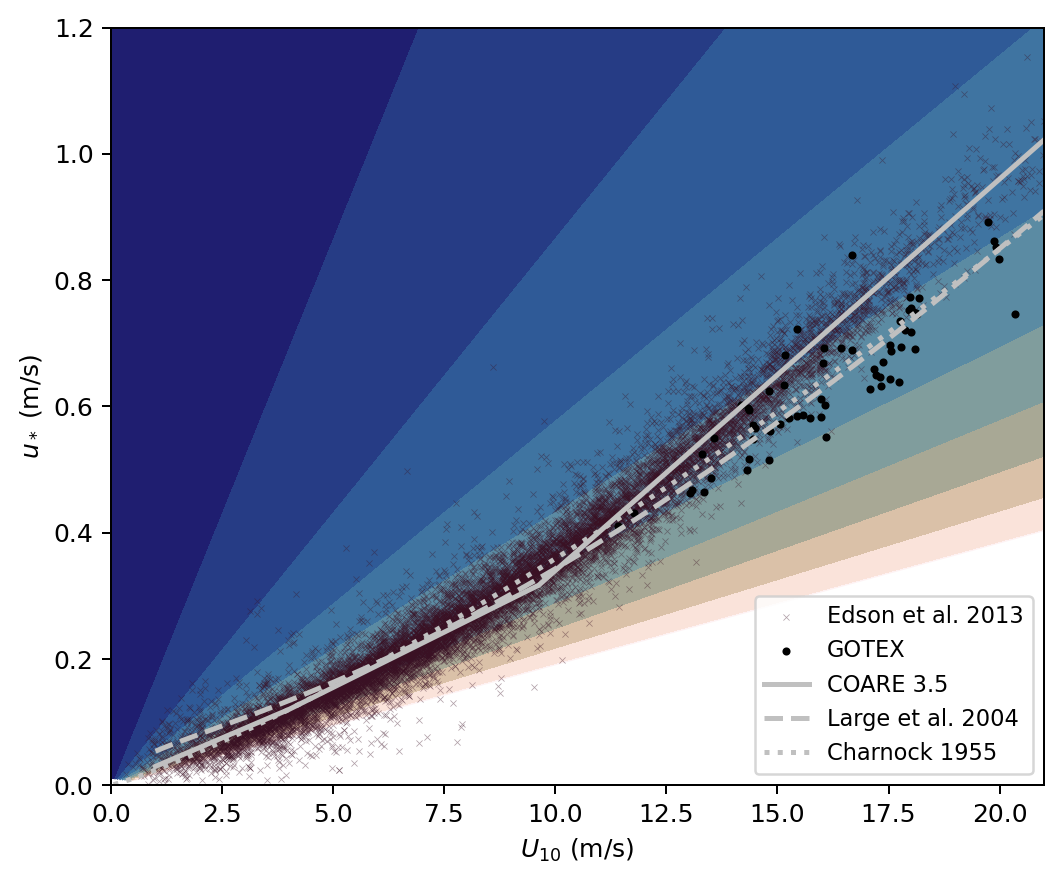

In [2]:
xlim = (0, 21)
ylim = (0, 1.2)

# ~ to check against aspect ratio in Edson et al
# fig, ax = coare_plot_starter(figsize=(12,4.85))

# ~  z0 contours under edson, coare, romero
fig, ax = coare_plot_starter(figsize=(6,5), colormode='dark')
coare_color_by_z0(ax, xlim, ylim)

# ~ just z0 contours
# fig, ax = coare_color_by_z0(False, xlim, ylim)
# plot_coare(ax, label='COARE 3.5 (Edson et al. 2013)')

plot_ncar(ax, lw=2, color='silver')
plot_charnock(ax, ls=':', lw=2, color='silver')

ax.legend(loc='lower right', fontsize=9)
# plt.savefig('figures/z0_contours.pdf')

# Compare Equilibrium vs. JONSWAP in LES (using NGA)

## together

In [ ]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

U18cases = ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match']
U_ids = ['Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
       'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       'Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
       'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched']

U_cases = ['HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'HS12_kp16_swell', 'kp16_js', 'kp16_js_match']

U24cases = ['U24_'+cname for cname in U_cases]
U24ids = ['U24 '+idname for idname in U_ids]

U12cases = ['U12_'+cname for cname in U_cases]
U12ids = ['U12 '+idname for idname in U_ids]

U18ids = ['U18 '+idname for idname in U_ids]

cases = U12cases + U18cases + U24cases
ids = U12ids + U18ids + U24ids

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)


### COARE plot ($U_{10}$ vs. $u_\ast$)

/home/hhwilliams/Documents/spectrum_farm/ocean-wave-spectrum-parameterizations/les_helpers.py:236: RuntimeWarning: invalid value encountered in sqrt
  label='Edson et al. 2013', zorder=1)


Text(0.8, 0.42, '$U_0$ = 24 m/s')

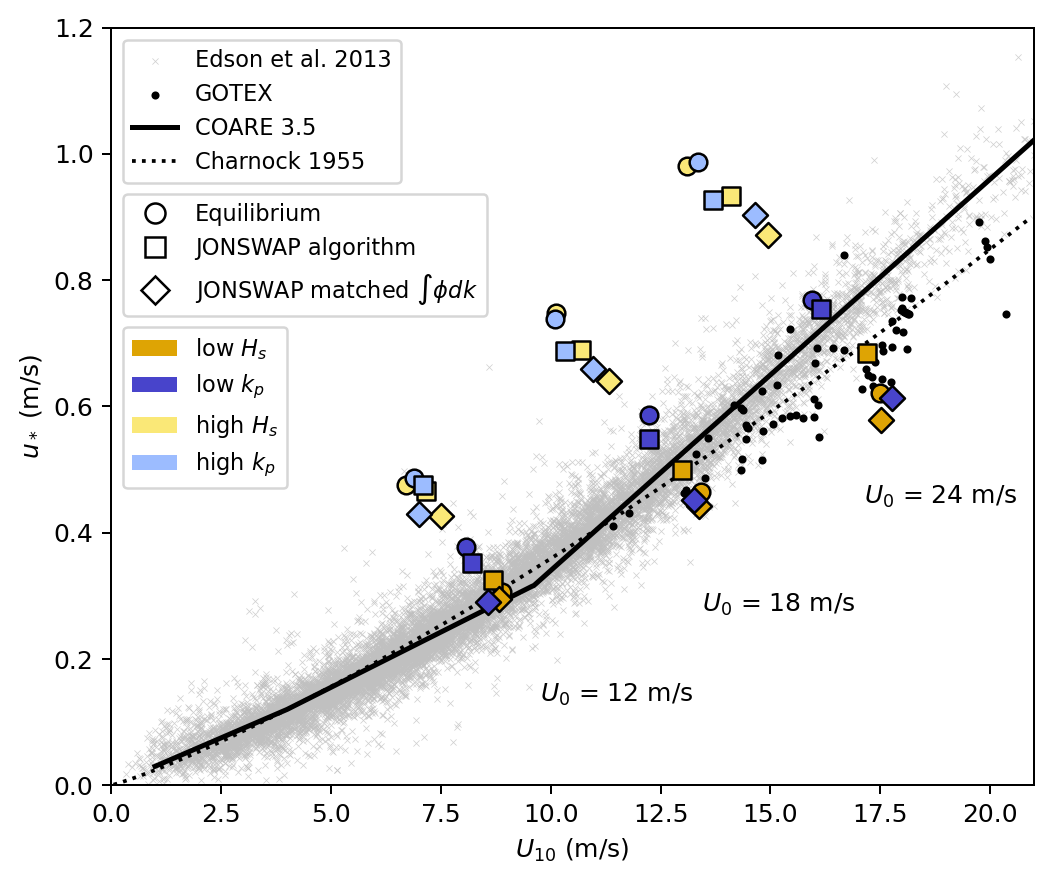

In [16]:
rcParams.update({'font.size': 10})
z_us = [0,100]

fig, ax = coare_plot_starter(figsize=(6,5), colormode='light')

ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
# ustars = [stat.ustar for stat in statlist.values()] # * for u* computed by NGA
u10s = [stat.Uz(10) for stat in statlist.values()]

# * to extract u* data
# print('USTARS:')
# print('\n'.join([id+', {:.3f}'.format(us) for id, us in zip(ids, ustars)]))

colors = ['#DEA404', '#4844CB', '#FAE877', '#9CBCFF']
markers = ['o', 's', 'D']

colors = colors + colors + colors

for i in range(len(statlist)):
    ax.scatter(u10s[i], ustars[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    

plot_charnock(ax, color='k', ls=':', label='Charnock 1955')

# * build legend
shape_labels = ['Equilibrium', 'JONSWAP algorithm', r'JONSWAP matched $\int\phi dk$']
shape_handles = [
    Line2D([0], [0], marker=m, color='k', markerfacecolor='white',
           linestyle='None', markersize=8)
    for m in markers ]
color_labels = [r'low $H_s$',
                r'low $k_p$',
                r'high $H_s$',
                r'high $k_p$',
                ]
color_handles = [Patch(facecolor=c, edgecolor='none')
                 for c in colors ]

handles, labels = ax.get_legend_handles_labels()

leg1 = ax.legend(handles, labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.999))
leg2 = ax.legend(shape_handles, shape_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.795))
leg3 = ax.legend(color_handles, color_labels, fontsize=9,
                 loc="upper left",
                 bbox_to_anchor=(0.001, 0.62))

ax.add_artist(leg1)
ax.add_artist(leg2)

ax.annotate(r'$U_0$ = 12 m/s', (0.5, 0.2), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 18 m/s', (0.65, 0.3), xycoords='figure fraction')
ax.annotate(r'$U_0$ = 24 m/s', (0.8, 0.42), xycoords='figure fraction')

# fig.savefig('figures/les_comparison.pdf')

get values of $c_p/u_\ast$ and $c_p/U_{10}$ for Equilibrium cases at $U_0$ = 18 m/s

In [ ]:

cps = [11.18, 15.80, 11.18, 7.91]

cases = ['U18_HS04_kp07_swell',
        'U18_HS12_kp04_swell', 
        'U18_HS20_kp07_swell', 
        'U18_HS12_kp16_swell']
U_ids = ['low Hs', 'low kp', 'high Hs', 'high kp']

caseids = [case+'/'+case for case in cases]
statlist = make_statlist(caseids, ids, case_info)

ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
# ustars = [stat.ustar for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]

for i in range(len(cps)):
    print(U_ids[i])
    print('cp/u*: {:.2f}'.format(cps[i]/ustars[i]))
    print('cp/U10: {:.2f}'.format(cps[i]/u10s[i]))

#     print('\n u*: {:.2f}'.format(ustars[i+12]))
    print('\nu*: {:.2f}'.format(ustars[i]))
    print('U10: {:.2f}'.format(u10s[i]))
    print('__\n')


low Hs
cp/u*: 24.09
cp/U10: 0.83

u*: 0.46
U10: 13.43
__

low kp
cp/u*: 26.93
cp/U10: 1.29

u*: 0.59
U10: 12.24
__

high Hs
cp/u*: 14.96
cp/U10: 1.10

u*: 0.75
U10: 10.13
__

high kp
cp/u*: 10.72
cp/U10: 0.78

u*: 0.74
U10: 10.10
__



### to plot vertical profiles

In [3]:
def wavecase_statlist(cases, label):
    case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

    ids = ['Equilibrium', 'JONSWAP \nfrom algorithm', 'JONSWAP \nmatched energy']
    ids = [label+' '+id for id in ids]

    caseids = [case+'/'+case for case in cases]
    statlist = make_statlist(caseids, ids, case_info)

    return statlist, ids

In [4]:
def plot_wave_profiles(statlist, ids, axs, color, xlabel=False, labels=False):
    ls = ['-','--',':']
    colors = [color for i in range(len(ids))]

    plot_velocity(statlist, ids, colors, 
              axs=axs[0:2], labels=labels,
              linestyles=ls, xlabel=xlabel,
              )
    
    print('')

    plot_upvp(statlist, ids, colors, ax=axs[2], labels=False, xlabel=xlabel,
          linestyles=ls)
    
    plot_tke(statlist, ids, colors, ax=axs[3], labels=False, xlabel=xlabel,
          linestyles=ls)




### just one case (HS20)



HS20 Equilibrium
U(150): 20.7
U(20): 15.2
U(10): 13.1

HS20 JONSWAP 
from algorithm
U(150): 21.1
U(20): 16.0
U(10): 14.1

HS20 JONSWAP 
matched energy
U(150): 21.3
U(20): 16.7
U(10): 14.9

TKE(150) for HS20 Equilibrium              : 3.76
TKE(20) for HS20 Equilibrium              : 4.29

TKE(150) for HS20 JONSWAP from algorithm   : 3.44
TKE(20) for HS20 JONSWAP from algorithm   : 3.97

TKE(150) for HS20 JONSWAP matched energy   : 2.99
TKE(20) for HS20 JONSWAP matched energy   : 3.43



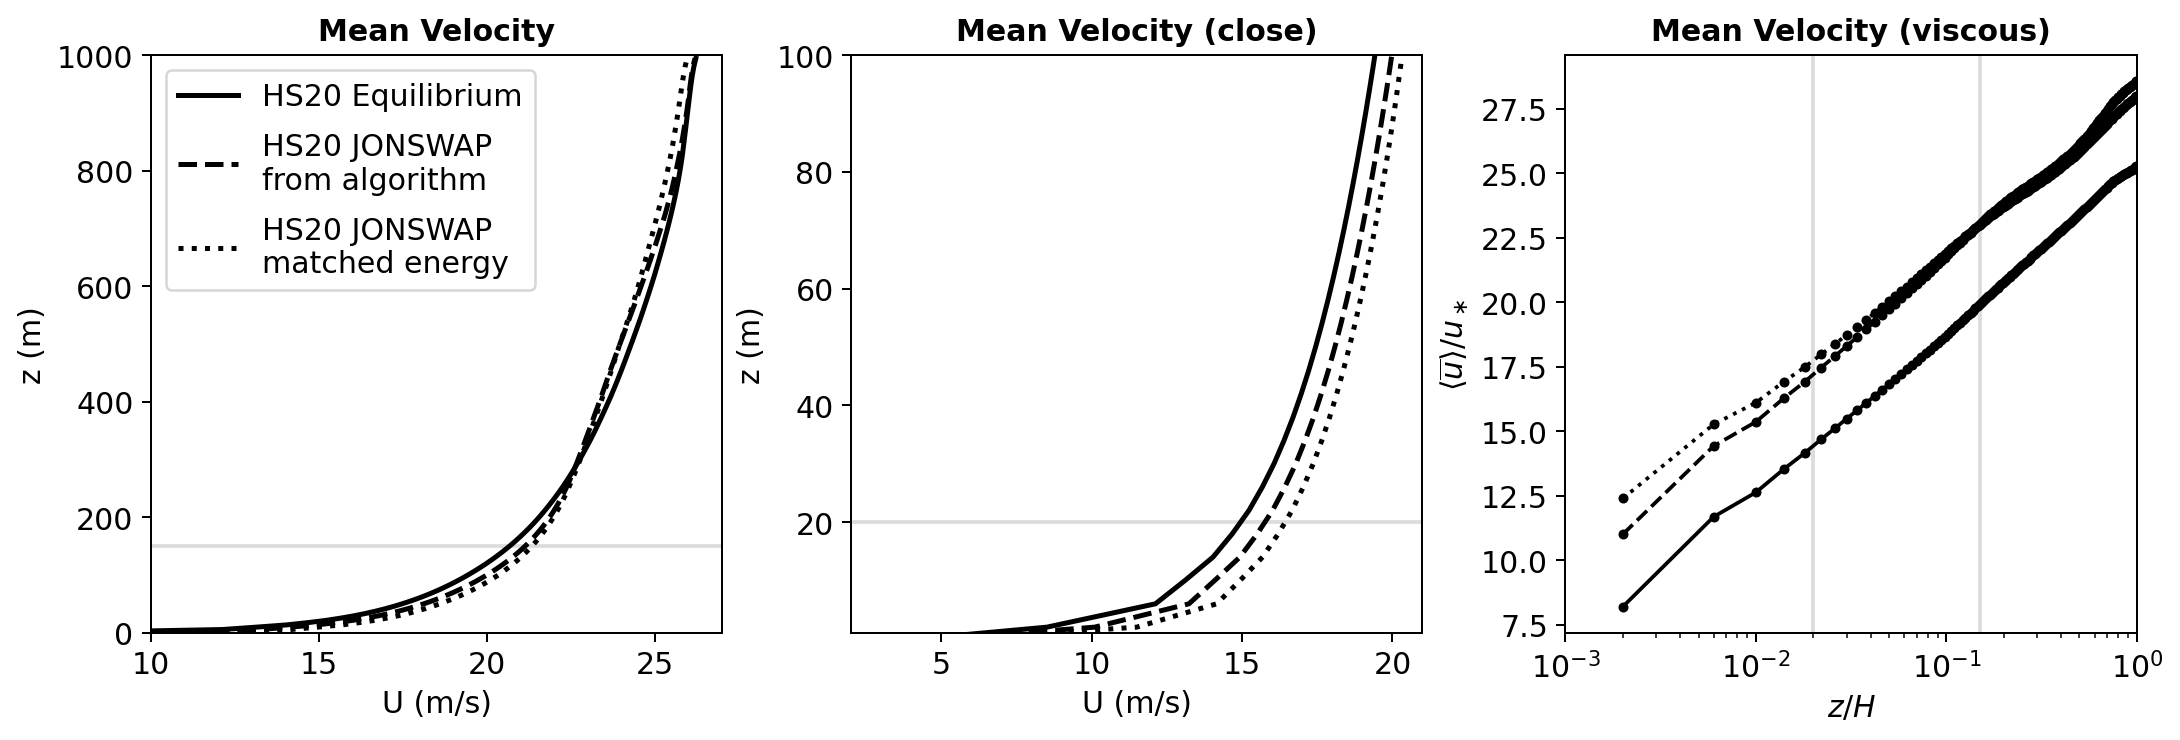

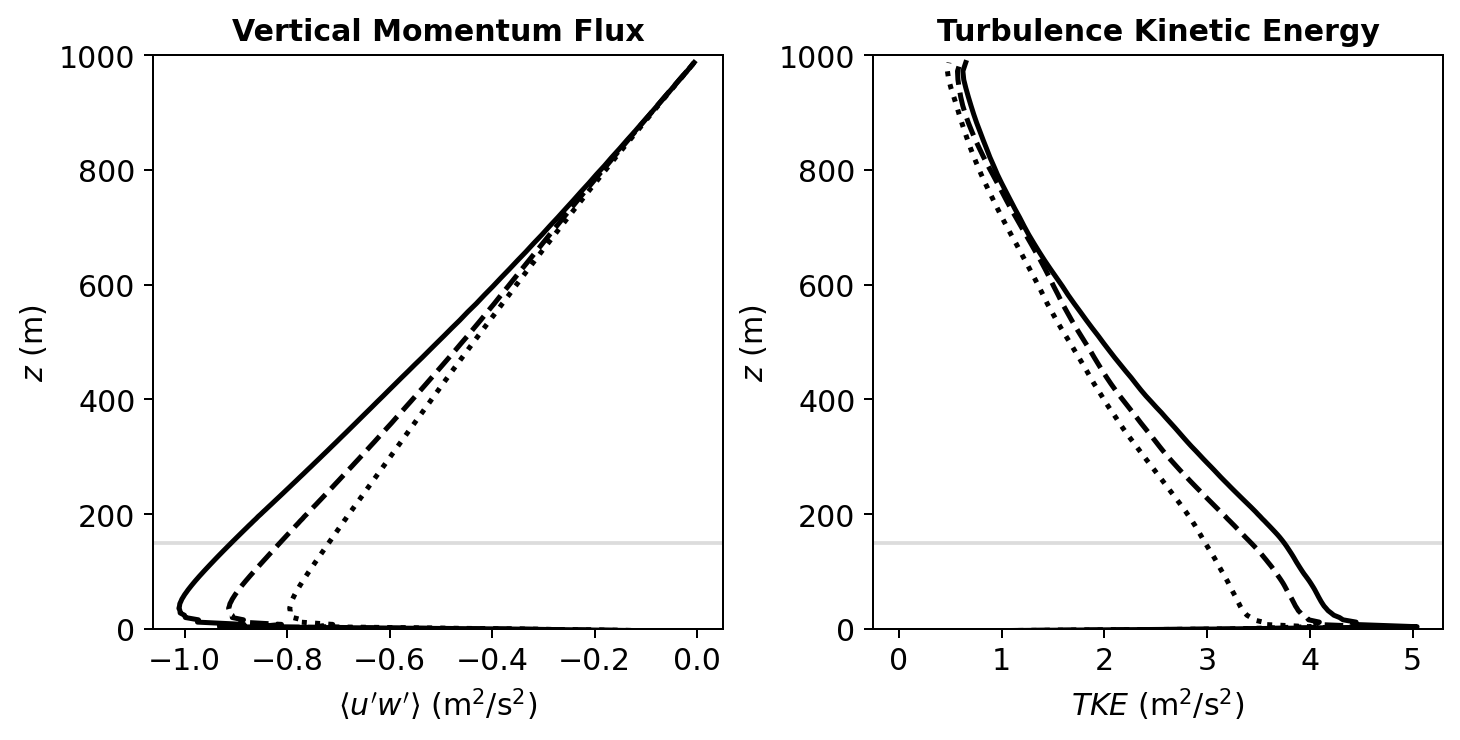

In [5]:
hs20_statlist, hs20_ids = wavecase_statlist(
    U24cases[6:9], 'HS20',
    )

rcParams.update({'font.size': 12})

fig1, axs1 = plt.subplots(1,3,facecolor='w', dpi=180.0, figsize=(12,4))
fig2, axs2 = plt.subplots(1,2,facecolor='w', dpi=180.0, figsize=(8,4))

color = 'k'
ls = ['-','--',':']
colors = [color for i in range(len(ids))]

plot_velocity(hs20_statlist, hs20_ids, colors, 
        axs=axs1, labels=True,
        linestyles=ls, xlabel=True,
        )

plot_upvp(hs20_statlist, hs20_ids, colors, ax=axs2[0], labels=False, xlabel=True,
        linestyles=ls)

plot_tke(hs20_statlist, hs20_ids, colors, ax=axs2[1], labels=False, xlabel=True,
        linestyles=ls)


fw = 'semibold'
fs = 12
axs1[0].set_title('Mean Velocity', weight=fw, fontsize=fs)
axs1[1].set_title('Mean Velocity (close)', weight=fw, fontsize=fs)
axs1[2].set_title('Mean Velocity (viscous)', weight=fw, fontsize=fs)
axs2[0].set_title('Vertical Momentum Flux', weight=fw, fontsize=fs)
axs2[1].set_title('Turbulence Kinetic Energy', weight=fw, fontsize=fs)

fig1.set_constrained_layout(True)
fig2.set_constrained_layout(True)

# fig1.savefig('figures/hs20_profiles_1.pdf')
# fig2.savefig('figures/hs20_profiles_2.pdf')

# plotting equivalent $z_0$ changes

In [13]:
case_info = pd.read_excel('les_data/sf_case_log.xlsx', sheet_name='bl_coare_sweep', header=1, index_col=0)

U18cases = ['U18_HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'U18_HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'U18_HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'U18_HS12_kp16_swell', 'kp16_js', 'kp16_js_match']
U_ids = ['Hs04 Equilibrium', 'Hs04 JONSWAP naive', 'Hs04 JONSWAP matched',
       'kp04 Equilibrium', 'kp04 JONSWAP naive', 'kp04 JONSWAP matched',
       'Hs12 Equilibrium', 'Hs12 JONSWAP naive', 'Hs12 JONSWAP matched',
       'kp16 Equilibrium', 'kp16 JONSWAP naive', 'kp16 JONSWAP matched']

U_cases = ['HS04_kp07_swell', 'HS04_js', 'HS04_js_match',
        'HS12_kp04_swell', 'kp04_js', 'kp04_js_match',
        'HS20_kp07_swell', 'HS20_js', 'HS20_js_match',
        'HS12_kp16_swell', 'kp16_js', 'kp16_js_match']

U24cases = ['U24_'+cname for cname in U_cases]
U24ids = ['U24 '+idname for idname in U_ids]

U12cases = ['U12_'+cname for cname in U_cases]
U12ids = ['U12 '+idname for idname in U_ids]

U18ids = ['U18 '+idname for idname in U_ids]

cases = U12cases + U18cases + U24cases
ids = U12ids + U18ids + U24ids

caseids = [case+'/'+case for case in cases]

statlist = make_statlist(caseids, ids, case_info)



z_us = [0, 100]
ustars = [stat.flux_ustar(z_us) for stat in statlist.values()]
u10s = [stat.Uz(10) for stat in statlist.values()]
z0s = [z0(u10, us) for u10, us in zip(u10s, ustars)]

colors = ['#DEA404', '#4844CB', '#FAE877', '#9CBCFF']
colors = np.tile(colors, 3)


In [20]:
def add_shape_legend(ax):
    shape_labels = ['Equilibrium', 'JONSWAP algorithm', r'JONSWAP matched $\int\phi dk$']
    shape_handles = [
        Line2D([0], [0], marker=m, color='k', markerfacecolor='white',
            linestyle='None', markersize=8)
        for m in markers ]
    leg1 = ax.legend(shape_handles, shape_labels, fontsize=9,
                    loc="upper left",
                    bbox_to_anchor=(1.001, 0.745))

    ax.add_artist(leg1)
    return leg1

In [21]:
def add_color_legend(ax):
    color_labels = [r'low $H_s$',# ($H_sk_p$=0.031)',
                    r'low $k_p$',# ($H_sk_p$=0.047)',
                    r'high $H_s$',# ($H_sk_p$=0.157)',
                    r'high $k_p$',# ($H_sk_p$=0.188)']
    ]
    color_handles = [
        Patch(facecolor=c, edgecolor='none')
        for c in colors ]

    leg2 = ax.legend(color_handles, color_labels, fontsize=9,
                    loc="upper left",
                    bbox_to_anchor=(1.001, 0.5))

    ax.add_artist(leg2)
    return leg2

### $z_0$ vs. $U_{bulk}$

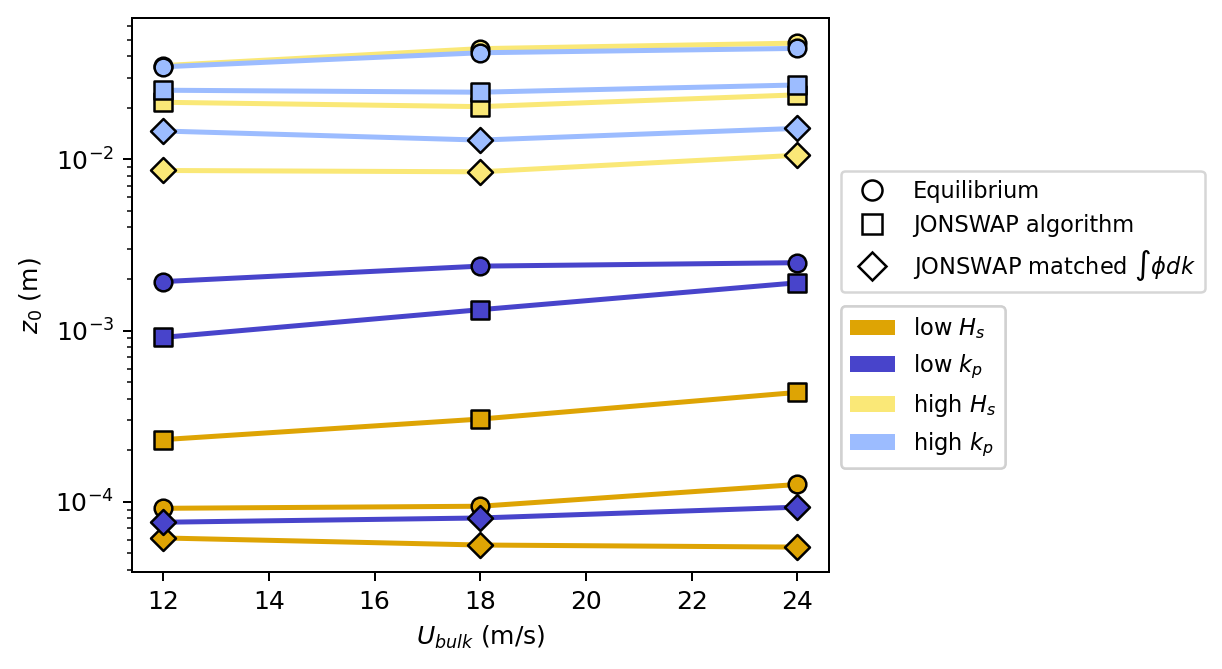

In [25]:

xs = np.repeat([12, 18, 24], 12)
# print(xs)

markers = ['o', 's', 'D']

fig = plt.figure(dpi=180.0, figsize=(5,4))

# eyes = np.arange(int(len(statlist)/3)) * 3 + 1
for i in range(12):
    xdata = [xs[j] for j in [i, i+12, i+24]]
    ydata = [z0s[j] for j in [i, i+12, i+24]]
    plt.plot(xdata, ydata,
             color=colors[int(i/3)], lw=2, zorder=2)

for i in range(len(statlist)):
    plt.scatter(xs[i], z0s[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    
plt.yscale('log')

plt.xlabel(r'$U_{bulk}$ (m/s)')
plt.ylabel(r'$z_0$ (m)')

# * legend
ax = plt.gca()
leg1 = add_shape_legend(ax)
leg2 = add_color_legend(ax)

fig.savefig('figures/z0_by_ubulk.pdf', 
            bbox_inches='tight',
            bbox_extra_artists=(leg1,leg2)
            )

### $z_0$ by parameterization type

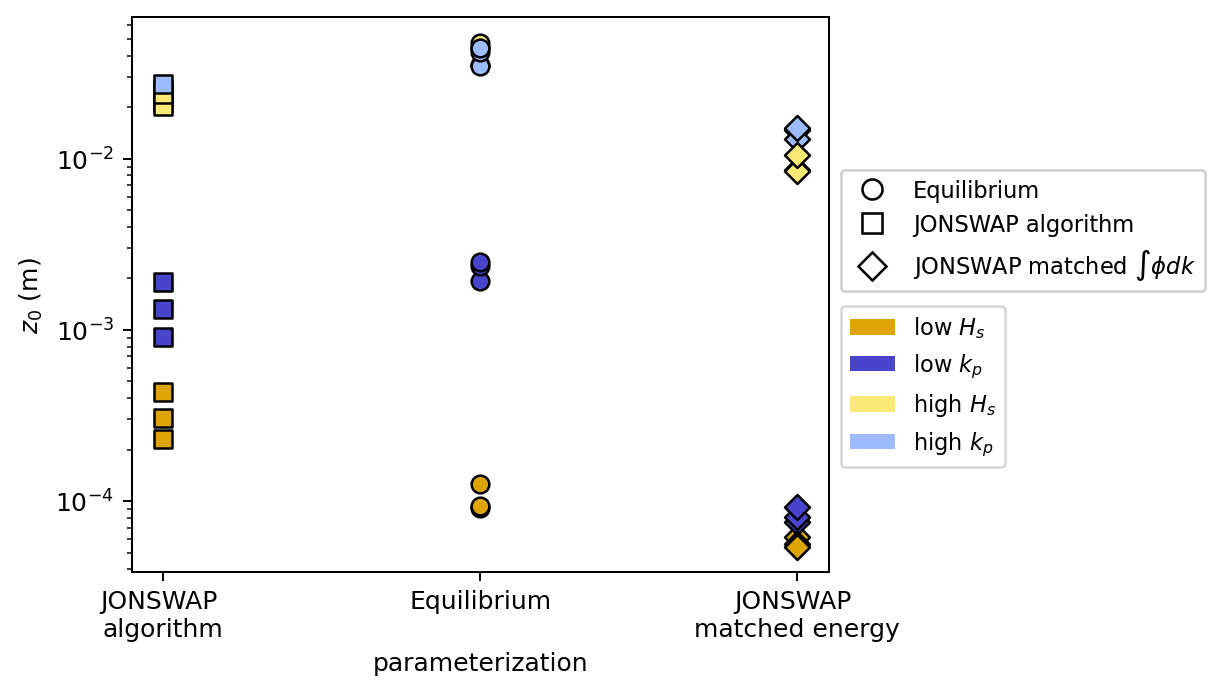

In [26]:

xs = np.tile([1, 0, 2], 12)
markers = ['o', 's', 'D']

fig = plt.figure(dpi=180.0, figsize=(5,4))

eyes = np.arange(int(len(statlist)/3)) * 3 + 1
# print(eyes)
# for i in eyes:
#     xdata = [xs[j] for j in [i, i-1, i+1]]
#     ydata = [z0s[j] for j in [i, i-1, i+1]]
#     plt.plot(xdata, ydata,
#              color=colors[int(i/3)], lw=2, zorder=2)

for i in range(len(statlist)):
    plt.scatter(xs[i], z0s[i], c=colors[int(i/3)], marker=markers[i%3],
               zorder=3, edgecolor='black', s=50)
    
plt.yscale('log')

plt.xlabel('parameterization')
plt.ylabel(r'$z_0$ (m)')

xlabels = ['JONSWAP \nalgorithm', 'Equilibrium', 'JONSWAP \nmatched energy']
plt.xticks([0,1,2], xlabels)

# * legend
ax = plt.gca()
leg1 = add_color_legend(ax)
leg2 = add_shape_legend(ax)

fig = plt.savefig('figures/z0_by_param.pdf',
                  bbox_inches='tight',
                  bbox_extra_artists=(leg1,leg2)
                  )

<!-- # misc other stuff -->